# 📊 Logistic Regression (Manual vs Scikit-learn)

## Objective:
To understand Logistic Regression by implementing it manually using mathematical concepts and comparing it with Scikit-learn implementation.

## 📦 Importing Libraries  

Importing required libraries for data handling, modeling, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


## 📂 Dataset Preparation  

Creating a simple dataset with Age as input and Pass/Fail as output.

In [2]:
data = {
    "Age": [20, 25, 30, 35, 40],
    "y_true": [0, 0, 0, 1, 1]
}
df = pd.DataFrame(data)
df

,Age,y_true
0,20,0
1,25,0
2,30,0
3,35,1
4,40,1


## 🧮 Manual Logistic Regression  

Applying the logistic function manually using predefined coefficients.

In [3]:
#MLE

m = 0.06
c = -1.4

df["z"] = m * df["Age"] + c

df["y_pred_manual"] = 1 / (1 + np.exp(-df["z"]))

## 📉 Log Loss Calculation  

Calculating log loss manually to measure model performance.

In [4]:
df["log_loss_manual"] = -(df["y_true"] * np.log(df["y_pred_manual"]) +
                          (1 - df["y_true"]) * np.log(1 - df["y_pred_manual"]))

# Average log loss
avg_manual_loss = df["log_loss_manual"].mean()
print(f"Average Manual Log Loss: {avg_manual_loss:.4f}")


Average Manual Log Loss: 0.5944


### 🔍 Observation:
Lower log loss indicates better model performance and accurate probability predictions.

## 🤖 Logistic Regression using Scikit-learn  

Training model using built-in LogisticRegression and comparing results.

In [5]:
# -----------------------------
# Step 3: Using sklearn Logistic Regression
# -----------------------------
X = df[["Age"]]
y = df["y_true"]

model = LogisticRegression()
model.fit(X, y)

# Predicted probabilities
df["y_pred_sklearn"] = model.predict_proba(X)[:, 1]

# sklearn log loss
avg_sklearn_loss = log_loss(y, df["y_pred_sklearn"])
print(f"Average sklearn Log Loss: {avg_sklearn_loss:.4f}")

Average sklearn Log Loss: 0.0601


## 🔄 Manual vs Scikit-learn Comparison  

Comparing predicted probabilities and log loss values.

In [6]:
# -----------------------------
# Step 4: Compare Results
# -----------------------------
print("\nComparison Table:")
display(df[["Age", "y_true", "y_pred_manual", "y_pred_sklearn", "log_loss_manual"]])


Comparison Table:


,Age,y_true,y_pred_manual,y_pred_sklearn,log_loss_manual
0,20,0,0.450166,0.000097,0.598139
1,25,0,0.524979,0.003884,0.744397
2,30,0,0.598688,0.135961,0.913015
3,35,1,0.668188,0.863943,0.403186
4,40,1,0.731059,0.996113,0.313262


### 🔍 Observation:
Scikit-learn model provides optimized coefficients, resulting in better performance compared to manual assumptions.

## 📊 Visualization  

Plotting probability curves for manual and sklearn models.

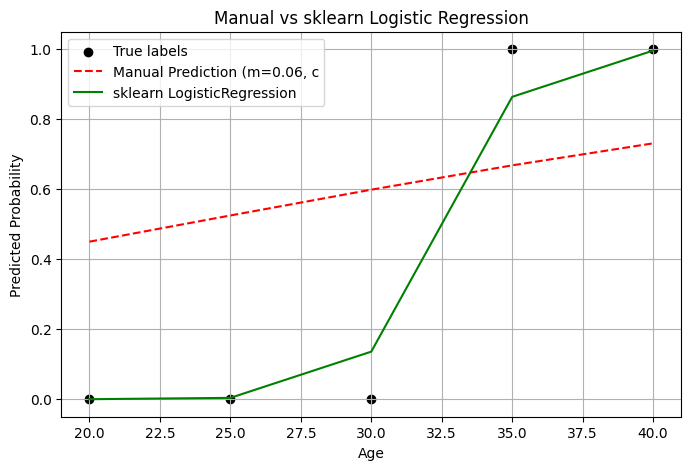

In [ ]:

# -----------------------------
# Step 5: Visualization
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["y_true"], color='black', label='True labels')
plt.plot(df["Age"], df["y_pred_manual"], 'r--', label='Manual Prediction (m=0.06, c')
plt.plot(df["Age"], df["y_pred_sklearn"], 'g-', label='sklearn LogisticRegression')
plt.xlabel("Age")
plt.ylabel("Predicted Probability")
plt.title("Manual vs sklearn Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
model.intercept_

array([-24.0353268])

In [9]:
model.coef_

array([[0.73953589]])

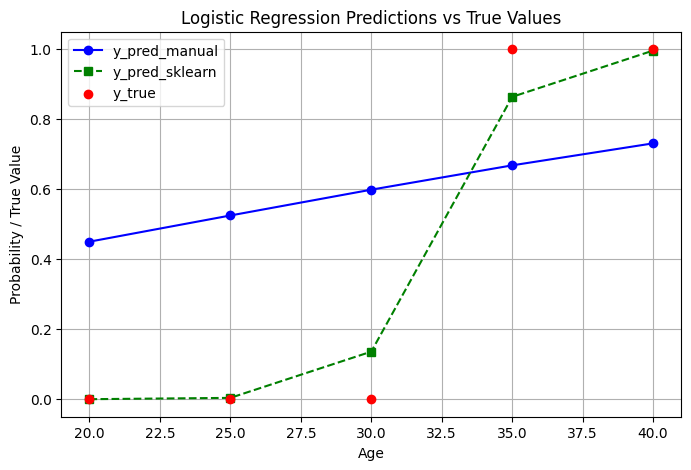

In [10]:
import matplotlib.pyplot as plt

Age = [20, 25, 30, 35, 40]
y_true = [0, 0, 0, 1, 1]
y_pred_manual = [0.450166, 0.524979, 0.598688, 0.668188, 0.731059]
y_pred_sklearn = [0.000097, 0.003884, 0.135961, 0.863943, 0.996113]

plt.figure(figsize=(8,5))
plt.plot(Age, y_pred_manual, marker='o', linestyle='-', color='blue', label='y_pred_manual')
plt.plot(Age, y_pred_sklearn, marker='s', linestyle='--', color='green', label='y_pred_sklearn')
plt.scatter(Age, y_true, color='red', label='y_true', zorder=5)

plt.xlabel('Age')
plt.ylabel('Probability / True Value')
plt.title('Logistic Regression Predictions vs True Values')
plt.grid(True)
plt.legend()
plt.show()


## 📐 Multivariate Logistic Regression  

Extending model to multiple features (Age + Income).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression


X = np.array([
    [25, 40],
    [32, 60],
    [47, 80],
    [51, 75],
    [62, 90]
])
y = np.array([0, 0, 1, 1, 1])

# MANUAL MODEL
m0, m1, m2 = -4, 0.1, 0.05

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_manual = m0 + m1 * X[:, 0] + m2 * X[:, 1]
p_manual = sigmoid(z_manual)
log_loss_manual = -(y * np.log(p_manual) + (1 - y) * np.log(1 - p_manual))
avg_loss_manual = np.mean(log_loss_manual)

print("z_manual:",z_manual)


z_manual: [0.5  2.2  4.7  4.85 6.7 ]


## 🔄 Multivariate Comparison  

Comparing coefficients, probabilities, and log loss.

In [12]:

# SKLEARN MODEL
lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lr.fit(X, y)
intercept = lr.intercept_[0]
coef = lr.coef_[0]

z_sklearn = intercept + coef[0] * X[:, 0] + coef[1] * X[:, 1]
p_sklearn = sigmoid(z_sklearn)
log_loss_sklearn = -(y * np.log(p_sklearn) + (1 - y) * np.log(1 - p_sklearn))
avg_loss_sklearn = np.mean(log_loss_sklearn)

# COMPARISON TABLE
comparison = pd.DataFrame({
    'Person': ['A', 'B', 'C', 'D', 'E'],
    'Age': X[:, 0],
    'Income': X[:, 1],
    'y_true': y,
    'z_manual': z_manual.round(4),
    'p_manual': p_manual.round(4),
    'logloss_manual': log_loss_manual.round(4),
    'z_sklearn': z_sklearn.round(4),
    'p_sklearn': p_sklearn.round(4),
    'logloss_sklearn': log_loss_sklearn.round(4)
})

print("\n=== MANUAL vs SKLEARN COMPARISON ===")
print(comparison)
print(f"\nAverage Manual Log Loss: {avg_loss_manual:.4f}")
print(f"Average Sklearn Log Loss: {avg_loss_sklearn:.4f}")
print(f"\nManual Coefficients: m0={m0}, m1={m1}, m2={m2}")
print(f"Sklearn Coefficients: m0={intercept:.4f}, m1={coef[0]:.4f}, m2={coef[1]:.4f}")



=== MANUAL vs SKLEARN COMPARISON ===
  Person  Age  Income  y_true  z_manual  p_manual  logloss_manual  z_sklearn  \
0      A   25      40       0      0.50    0.6225          0.9741   -19.9203   
1      B   32      60       0      2.20    0.9002          2.3051   -10.9078   
2      C   47      80       1      4.70    0.9910          0.0091    11.4029   
3      D   51      75       1      4.85    0.9922          0.0078    18.7077   
4      E   62      90       1      6.70    0.9988          0.0012    35.0252   

   p_sklearn  logloss_sklearn  
0        0.0              0.0  
1        0.0              0.0  
2        1.0              0.0  
3        1.0              0.0  
4        1.0              0.0  

Average Manual Log Loss: 0.6594
Average Sklearn Log Loss: 0.0000

Manual Coefficients: m0=-4, m1=0.1, m2=0.05
Sklearn Coefficients: m0=-56.2303, m1=1.6623, m2=-0.1312


### 🔍 Observation:
Multivariate Logistic Regression captures more complex relationships and improves prediction accuracy.

## 🌐 3D Visualization  

Visualizing probability surfaces for manual and sklearn models.

In [13]:
import plotly.graph_objects as go

# 3D VISUALIZATION
age_range = np.linspace(20, 70, 50)
income_range = np.linspace(30, 100, 50)
Age_grid, Income_grid = np.meshgrid(age_range, income_range)

# Manual surface
Z_manual = m0 + m1 * Age_grid + m2 * Income_grid
P_manual = sigmoid(Z_manual)

# Sklearn surface
Z_sklearn = intercept + coef[0] * Age_grid + coef[1] * Income_grid
P_sklearn = sigmoid(Z_sklearn)


fig = go.Figure()

fig.add_trace(go.Surface(
    x=Age_grid,
    y=Income_grid,
    z=P_manual,
    colorscale='Reds',
    opacity=0.6,
    name='Manual Model'
))

fig.add_trace(go.Surface(
    x=Age_grid,
    y=Income_grid,
    z=P_sklearn,
    colorscale='Blues',
    opacity=0.6,
    name='Sklearn Model'
))

fig.add_trace(go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    mode='markers',
    marker=dict(size=6, color='black'),
    name='Actual Data'
))

fig.update_layout(
    title='Manual vs Sklearn Logistic Regression (Interactive 3D)',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Income',
        zaxis_title='Predicted Probability'
    ),
    legend=dict(x=0.05, y=0.95)
)

fig.show()


### 🔍 Final Insight:
Logistic Regression is effective for classification problems, and understanding its mathematical foundation helps in better model interpretation.